In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from sklearn.decomposition import PCA

# Cố định random seed để kết quả đồng nhất
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
os.makedirs("model_saved", exist_ok=True)
os.makedirs("figures", exist_ok=True)
print("CELL 1: Đã nạp thư viện thành công.")

CELL 1: Đã nạp thư viện thành công.


In [12]:
df_diabetes = pd.read_csv("diabetes.csv")
print("Kích thước tập dữ liệu:", df_diabetes.shape)
print("\n5 dòng đầu:")
display(df_diabetes.head())
print("\nThông tin kiểu dữ liệu:")
df_diabetes.info()

Kích thước tập dữ liệu: (768, 9)

5 dòng đầu:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Thông tin kiểu dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Thống kê mô tả trước khi xử lý:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Phân bố biến mục tiêu Outcome:
Outcome
0    500
1    268
Name: count, dtype: int64

Tỷ lệ phân bố:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


C:\Users\The Hoang\AppData\Local\Temp\ipykernel_11040\961985592.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_diabetes, x='Outcome', ax=ax[0], palette='Blues')


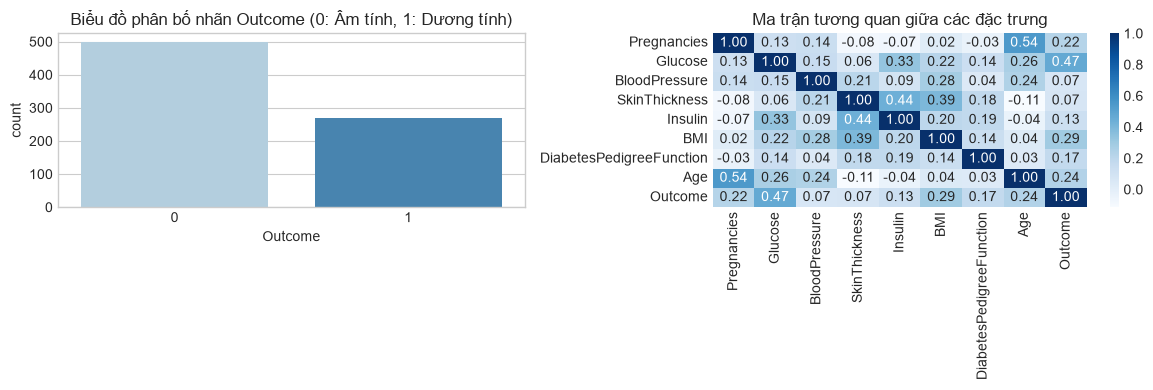

In [13]:
print("Thống kê mô tả trước khi xử lý:")
display(df_diabetes.describe())

# Kiểm tra phân bố nhãn Outcome
print("\nPhân bố biến mục tiêu Outcome:")
target_dist = df_diabetes['Outcome'].value_counts()
print(target_dist)
print("\nTỷ lệ phân bố:")
print(df_diabetes['Outcome'].value_counts(normalize=True))

# Biểu đồ phân bố nhãn và tương quan
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df_diabetes, x='Outcome', ax=ax[0], palette='Blues')
ax[0].set_title("Biểu đồ phân bố nhãn Outcome (0: Âm tính, 1: Dương tính)")

sns.heatmap(df_diabetes.corr(), annot=True, fmt='.2f', cmap='Blues', ax=ax[1])
ax[1].set_title("Ma trận tương quan giữa các đặc trưng")
plt.tight_layout()
plt.savefig("figures/fig_2_1_eda_diabetes.png", dpi=300)
plt.show()

In [14]:
# Các cột có giá trị 0 là phi lý về mặt sinh lý học
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_clean = df_diabetes.copy()
df_clean[zero_cols] = df_clean[zero_cols].replace(0, np.nan)

print("Số lượng giá trị khuyết thiếu thực tế (sau khi đổi 0 -> NaN):")
print(df_clean.isnull().sum())

X = df_clean.drop(columns=['Outcome']).values
y = df_clean['Outcome'].values

# Chia tập độc lập: Train (70%), Validation (15%), Test (15%) phân tầng theo y
X_train_raw, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

# Fit Imputer và Scaler CHỈ trên tập Train, sau đó Transform cho Val và Test
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train = scaler.fit_transform(imputer.fit_transform(X_train_raw))
X_val = scaler.transform(imputer.transform(X_val_raw))
X_test = scaler.transform(imputer.transform(X_test_raw))

print(f"\nKích thước sau tiền xử lý:")
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Số lượng giá trị khuyết thiếu thực tế (sau khi đổi 0 -> NaN):
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Kích thước sau tiền xử lý:
Train: (537, 8) | Val: (115, 8) | Test: (116, 8)


In [15]:
ml_models = {
    "Logistic Regression": LogisticRegression(random_state=SEED),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=SEED)
}

ml_results = []
for name, model in ml_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    ml_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs)
    })

df_ml_results = pd.DataFrame(ml_results)
print("BẢNG KẾT QUẢ CÁC MÔ HÌNH MACHINE LEARNING:")
display(df_ml_results)

BẢNG KẾT QUẢ CÁC MÔ HÌNH MACHINE LEARNING:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.775862,0.777778,0.512195,0.617647,0.862439
1,Decision Tree,0.767241,0.733333,0.536585,0.619718,0.728455
2,Random Forest,0.724138,0.680000,0.414634,0.515152,0.840650


In [16]:
# Mạng 5 tầng có tham số: Input(8) -> 128 -> 64 -> 32 -> 16 -> Output(2)
class DiabetesMLP5(nn.Module):
    def __init__(self, in_features=8, num_classes=2):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 32)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(32, 16)
        self.relu4 = nn.ReLU()
        self.fc5 = nn.Linear(16, num_classes)

    def forward(self, x):
        h1 = self.relu1(self.fc1(x))
        h2 = self.relu2(self.fc2(h1))
        h3 = self.relu3(self.fc3(h2))
        h4 = self.relu4(self.fc4(h3))
        out = self.fc5(h4)
        return out, h4 # Trả về h4 phục vụ khảo sát không gian ẩn (PCA)

dl_model = DiabetesMLP5(in_features=8, num_classes=2)
total_params = sum(p.numel() for p in dl_model.parameters() if p.requires_grad)
print("Cấu trúc mạng Deep Learning 5 Layer:\n", dl_model)
print(f"\nTổng số tham số học được (Trainable Parameters): {total_params:,}")

Cấu trúc mạng Deep Learning 5 Layer:
 DiabetesMLP5(
  (fc1): Linear(in_features=8, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (relu3): ReLU()
  (fc4): Linear(in_features=32, out_features=16, bias=True)
  (relu4): ReLU()
  (fc5): Linear(in_features=16, out_features=2, bias=True)
)

Tổng số tham số học được (Trainable Parameters): 12,050


In [17]:
# Chuyển đổi dữ liệu sang PyTorch Tensor
X_tr_t = torch.tensor(X_train, dtype=torch.float32)
y_tr_t = torch.tensor(y_train, dtype=torch.long)
X_va_t = torch.tensor(X_val, dtype=torch.float32)
y_va_t = torch.tensor(y_val, dtype=torch.long)
X_te_t = torch.tensor(X_test, dtype=torch.float32)
y_te_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dl_model.parameters(), lr=0.001)

epochs = 60
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, epochs + 1):
    dl_model.train()
    running_loss, correct_train = 0.0, 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits, _ = dl_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(yb)
        correct_train += (logits.argmax(1) == yb).sum().item()
    
    dl_model.eval()
    with torch.no_grad():
        v_logits, _ = dl_model(X_va_t)
        v_loss = criterion(v_logits, y_va_t).item()
        v_acc = (v_logits.argmax(1) == y_va_t).float().mean().item()
    
    history['train_loss'].append(running_loss / len(X_train))
    history['val_loss'].append(v_loss)
    history['train_acc'].append(correct_train / len(X_train))
    history['val_acc'].append(v_acc)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:02d}/{epochs} | Train Loss: {history['train_loss'][-1]:.4f} | Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.4f}")

Epoch 10/60 | Train Loss: 0.4077 | Val Loss: 0.5240 | Val Acc: 0.7043
Epoch 20/60 | Train Loss: 0.3301 | Val Loss: 0.5928 | Val Acc: 0.7130
Epoch 30/60 | Train Loss: 0.2508 | Val Loss: 0.6792 | Val Acc: 0.7478
Epoch 40/60 | Train Loss: 0.1469 | Val Loss: 0.8674 | Val Acc: 0.6522
Epoch 50/60 | Train Loss: 0.0770 | Val Loss: 1.1277 | Val Acc: 0.7217
Epoch 60/60 | Train Loss: 0.0604 | Val Loss: 1.4649 | Val Acc: 0.7130


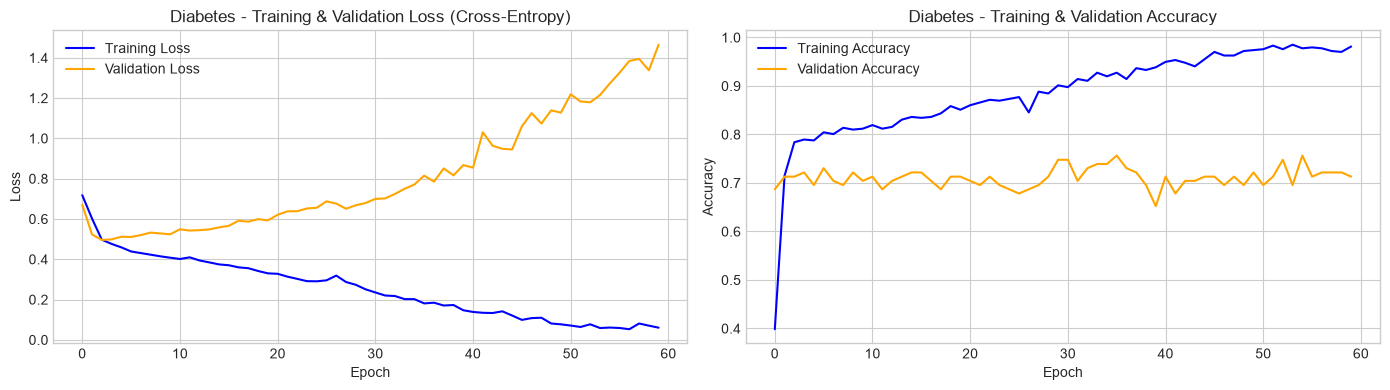

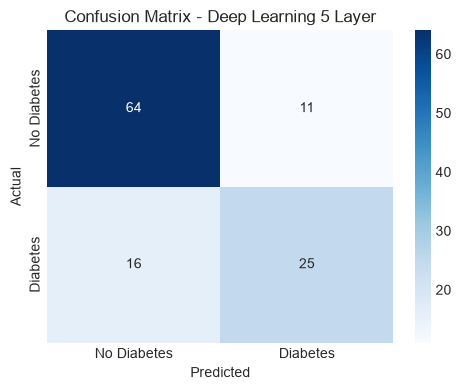

In [18]:
# 1. Vẽ Learning Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history['train_loss'], label='Training Loss', color='blue')
ax1.plot(history['val_loss'], label='Validation Loss', color='orange')
ax1.set_title("Diabetes - Training & Validation Loss (Cross-Entropy)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(history['train_acc'], label='Training Accuracy', color='blue')
ax2.plot(history['val_acc'], label='Validation Accuracy', color='orange')
ax2.set_title("Diabetes - Training & Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
plt.tight_layout()
plt.savefig("figures/fig_2_8_learning_curves_diabetes.png", dpi=300)
plt.show()

# 2. Đánh giá trên tập Test độc lập
dl_model.eval()
with torch.no_grad():
    test_logits, h4_test = dl_model(X_te_t)
    test_probs = torch.softmax(test_logits, dim=1)[:, 1].numpy()
    test_preds = test_logits.argmax(dim=1).numpy()

cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title("Confusion Matrix - Deep Learning 5 Layer")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("figures/fig_2_9_confusion_matrix_diabetes.png", dpi=300)
plt.show()

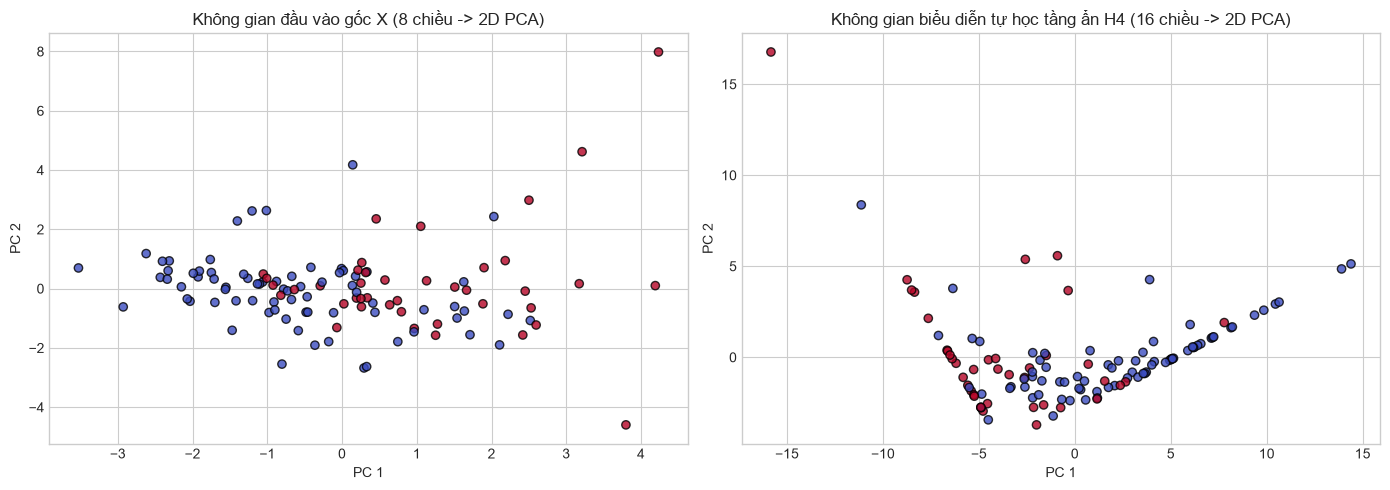


BẢNG ĐỐI SÁNH HIỆU NĂNG TỔNG HỢP (TEST SET):


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.775862,0.777778,0.512195,0.617647,0.862439
1,Decision Tree,0.767241,0.733333,0.536585,0.619718,0.728455
2,Random Forest,0.724138,0.680000,0.414634,0.515152,0.840650
3,Deep Learning 5-Layer,0.767241,0.694444,0.609756,0.649351,0.806016


CELL 9: Đã lưu mô hình và preprocessor thành công.


In [19]:
# So sánh không gian đầu vào X gốc và không gian tầng ẩn H4
pca_raw = PCA(n_components=2).fit_transform(X_test)
pca_h4 = PCA(n_components=2).fit_transform(h4_test.numpy())

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
scatter1 = ax[0].scatter(pca_raw[:, 0], pca_raw[:, 1], c=y_test, cmap='coolwarm', alpha=0.8, edgecolors='k')
ax[0].set_title("Không gian đầu vào gốc X (8 chiều -> 2D PCA)")
ax[0].set_xlabel("PC 1")
ax[0].set_ylabel("PC 2")

scatter2 = ax[1].scatter(pca_h4[:, 0], pca_h4[:, 1], c=y_test, cmap='coolwarm', alpha=0.8, edgecolors='k')
ax[1].set_title("Không gian biểu diễn tự học tầng ẩn H4 (16 chiều -> 2D PCA)")
ax[1].set_xlabel("PC 1")
ax[1].set_ylabel("PC 2")
plt.tight_layout()
plt.savefig("figures/fig_2_11_pca_representation_diabetes.png", dpi=300)
plt.show()

# Bảng so sánh tổng hợp cuối cùng
dl_res = {
    "Model": "Deep Learning 5-Layer",
    "Accuracy": accuracy_score(y_test, test_preds),
    "Precision": precision_score(y_test, test_preds),
    "Recall": recall_score(y_test, test_preds),
    "F1": f1_score(y_test, test_preds),
    "ROC-AUC": roc_auc_score(y_test, test_probs)
}
final_comparison = pd.concat([df_ml_results, pd.DataFrame([dl_res])], ignore_index=True)
print("\nBẢNG ĐỐI SÁNH HIỆU NĂNG TỔNG HỢP (TEST SET):")
display(final_comparison)

# Lưu trữ artifacts
joblib.dump(scaler, "model_saved/diabetes_scaler.joblib")
joblib.dump(imputer, "model_saved/diabetes_imputer.joblib")
torch.save(dl_model.state_dict(), "model_saved/diabetes_mlp5.pth")
print("CELL 9: Đã lưu mô hình và preprocessor thành công.")